# 06 Combining gravity and magnetics: Poisson analysis

For a body with uniform density rho and magnetisation M, Poisson's
relation ties the two fields together. At the pole it holds point by point:

    T_pole = Cm M / (G rho) * dg/dz

Integrating both sides vertically gives the same statement in smooth
quantities:

    pseudogravity(T) = (rho0 / M0) * (M / rho) * g

where rho0 and M0 are the nominal values used in the pseudogravity
transform. Either way, where gravity and magnetics come from the same
body the two fields are proportional, and a linear regression in a moving
window gives (Chandler and Malek 1991):

    slope         the magnetisation to density ratio M / rho
    correlation   how well the two fields share a source: near +-1 yes, near 0 no
    intercept     regional offset

`transforms.poisson_analysis` reduces the magnetics to the pole, forms the
pair of fields, puts them on the gravity geometry, applies the same band
pass to both, and runs the regression. `mode="pseudogravity"` (default)
regresses pseudogravity against gravity; `mode="derivative"` regresses
RTP magnetics against dg/dz.

Three settings decide whether the result means anything:

1. Low pass at the wavelength the gravity actually resolves. The grid is
   200 m but the stations are kilometres apart; anything shorter than
   about twice the station spacing is interpolation texture, and a
   vertical derivative amplifies it. 4 km here.
2. Remove the regional from both fields with the same high pass. Two
   smooth trends inside a window always correlate, so without this the
   map shows the regional, not shared sources. 40 km here.
3. A window large enough to hold whole anomalies at those wavelengths.
   20 km here. Smaller windows give speckle.

Units matter for the ratio: the SA GRAVITY 2016 grid is in mGal. The GA
national gravity grids are in um/s^2, ten times larger, and would put
`m_over_rho` out by a factor of ten.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

In [2]:
grav = read_grid(f"{DATA}/frome_grav.ers", units="mGal")          # MGA zone 54, 200 m
tmi = read_grid(f"{DATA}/frome_tmi.ers", epsg=28354, units="nT")
rtp = transforms.reduce_to_pole(tmi, INC, DEC)
print(grav); print(rtp)

Grid('frome_grav', 843x749, cell 200x200 m (~200x200 m), EPSG:28354, bounds W300909.0020 S6540668.9852 E450709.0020 N6709268.9852, units 'mGal')
Grid('frome_tmi_rtp', 1813x1564, cell 86.4396x86.4396 m (~86x86 m), EPSG:28354, bounds W307667.4377 S6546529.9920 E442858.9959 N6703245.0144, units 'nT')


## What not to do

Derivative form, no filtering, a 4 km window. Every window returns a
confident +-1 and the map is speckle: the regression is comparing real
magnetic detail with gridding noise in dg/dz.

<Axes: title={'center': 'correlation: derivative form, unfiltered, 4 km window'}, xlabel='Easting (km)', ylabel='Northing (km)'>

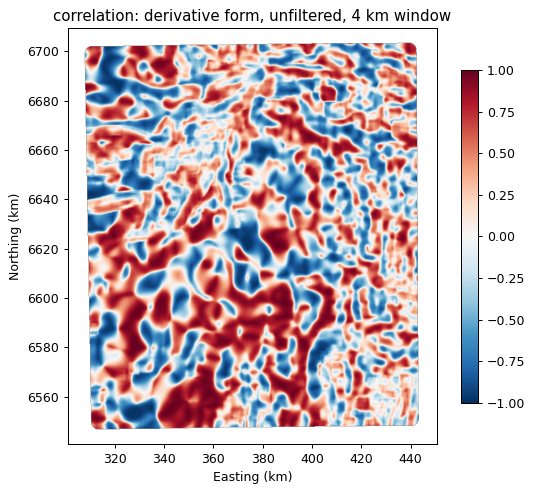

In [3]:
bad = transforms.poisson_analysis(grav, rtp, magnetics_is_rtp=True, mode="derivative", window_m=4000)
display.plot(bad["correlation"], cmap="RdBu_r", clip=(-1, 1), title="correlation: derivative form, unfiltered, 4 km window")

## Band-passed pseudogravity against gravity

The two regressed fields first. This side-by-side is the most readable
product of the exercise: where highs coincide the source is dense and
magnetic, where a high faces a low it is one but not the other.

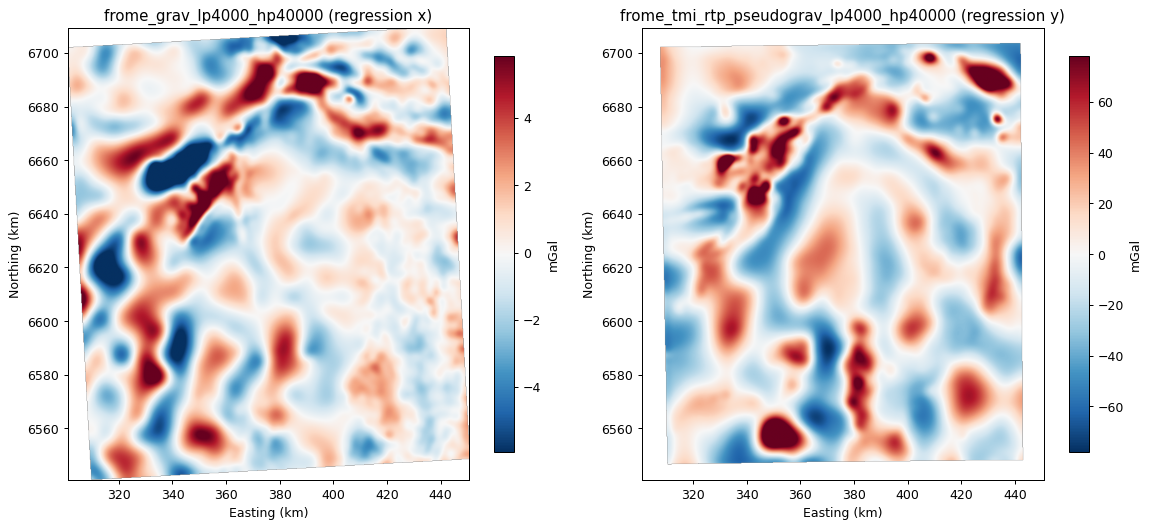

In [4]:
res = transforms.poisson_analysis(grav, rtp, magnetics_is_rtp=True, mode="pseudogravity",
                                  lowpass_wavelength=4000, regional_wavelength=40000, window_m=20000)
fig, axes = display.compare([res["x"], res["y"]], ncols=2, cmap="RdBu_r", clip=("std", 2.5), figsize_per=(6.5, 6))

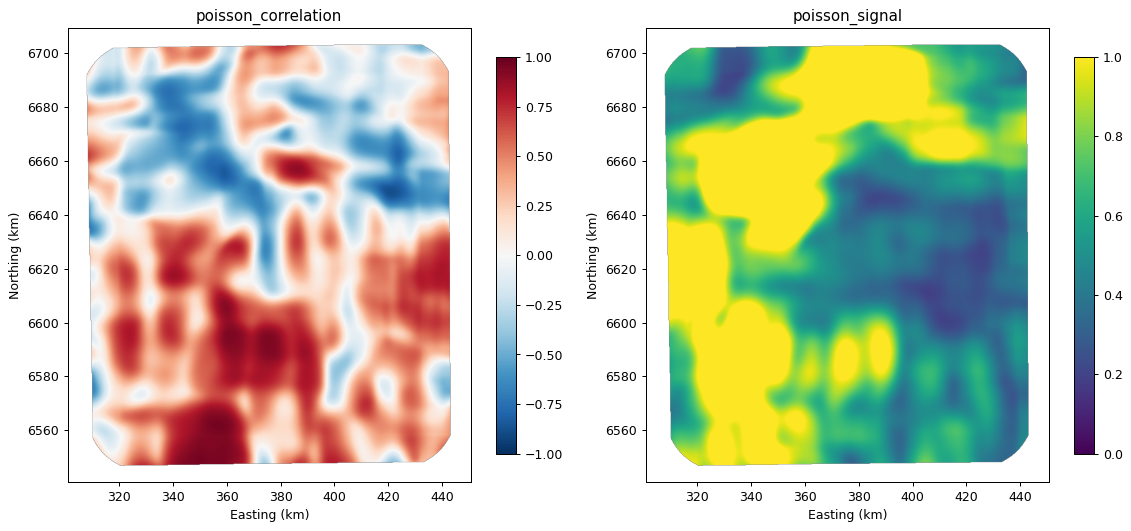

In [5]:
fig, axes = display.compare([res["correlation"], res["signal"]], ncols=2, cmap="RdBu_r", clip=(-1, 1), figsize_per=(6.5, 6))
axes[0, 1].images[0].set_cmap("viridis"); axes[0, 1].images[0].set_clim(0, 1)

`signal` is the standard deviation of the gravity input inside each
window divided by its standard deviation over the whole grid. Where it is
small the window holds no anomaly and the slope is meaningless whatever
the correlation says. Mask on both before reading the ratio.

18% of the area passes |r| > 0.6 and signal > 0.3


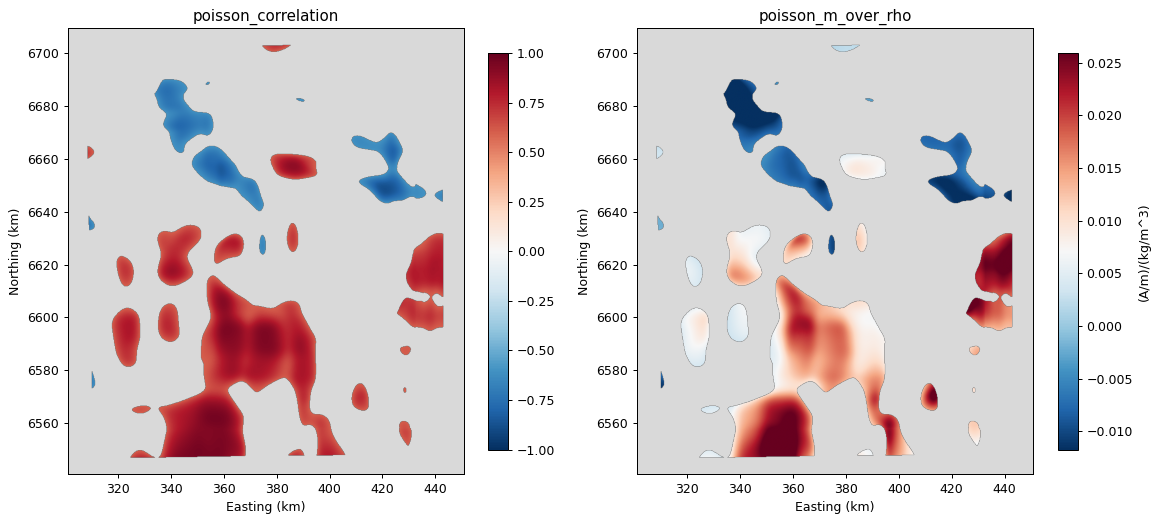

In [6]:
r = res["correlation"].values
keep = (np.abs(r) > 0.6) & (res["signal"].values > 0.3)
corr = res["correlation"].with_values(np.where(keep, r, np.nan))
ratio = res["m_over_rho"].with_values(np.where(keep, res["m_over_rho"].values, np.nan))
fig, axes = display.compare([corr, ratio], ncols=2, cmap="RdBu_r", clip=(-1, 1), figsize_per=(6.5, 6))
axes[0, 1].images[0].set_clim(*display.clip_limits(ratio.values, "pct", 5))
for ax in axes.ravel():
    ax.set_facecolor("0.85")
print(f"{np.nanmean(keep) * 100:.0f}% of the area passes |r| > 0.6 and signal > 0.3")

Reading the Frome result: the embayment in the south and centre comes out
with positive correlation, dense and magnetic basement under cover. The
Mount Painter and Mount Babbage inliers in the north are negative:
strongly magnetic but not dense, which fits granite and gneiss. In between
the correlation is moderate, meaning several lithologies share each 20 km
window or the two fields come from different bodies. That is the normal
outcome. The method was designed for terranes dominated by large mafic
intrusions, where both fields come from the same rock, and it is blunt
elsewhere. Vary the three settings and watch how much of the map survives.

Text(0.5, 1.0, 'all cells, coloured by local correlation')

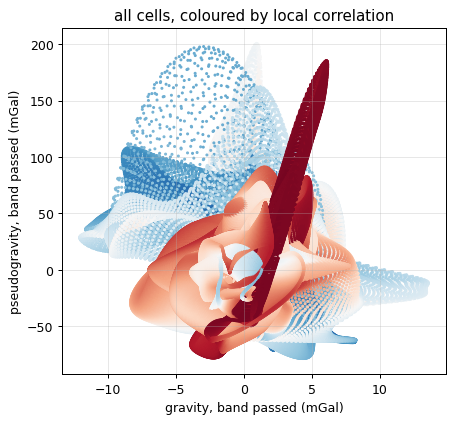

In [7]:
ok = np.isfinite(res["x"].values) & np.isfinite(res["y"].values)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(res["x"].values[ok], res["y"].values[ok], s=2, c=r[ok], cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("gravity, band passed (mGal)"); ax.set_ylabel("pseudogravity, band passed (mGal)"); ax.grid(alpha=0.3)
ax.set_title("all cells, coloured by local correlation")

In [8]:
import os
os.makedirs(OUT, exist_ok=True)
for key in ("correlation", "m_over_rho"):
    write_grid(res[key], f"{OUT}/frome_poisson_{key}.grd")